In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge
import networkx as nx
from pyproj import Transformer
import contextily as cx

In [2]:
data_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/centroids_k28_definitivo.csv"
# Leggi il file CSV
df_full = pd.read_csv(data_path, sep=';')

# Mostra le prime righe
df_full.head()

,id,species,stage,site,cycle,sex,age,capture_reg,capture_subreg,lon,...,type2,count_ind_sp,weight,wt_sp,wt_dur,wt_sp_sex,wt_ind,wt_ind_sp,next_cluster,cluster
0,100431_1,BLSC,W,W2,1,M,ASY,Southern New England,Rhode Island,-73.892804,...,W,89,1,2.940217,0.279338,5.909524,0.066667,0.000749,15.0,8
1,100431_1,BLSC,S,S1,1,M,ASY,Southern New England,Rhode Island,-62.408619,...,SM,89,1,2.940217,0.095890,5.909524,0.066667,0.000749,19.0,15
2,100431_1,BLSC,M,M1,1,M,ASY,Southern New England,Rhode Island,-80.532833,...,SM,89,1,2.940217,0.271233,5.909524,0.066667,0.000749,19.0,19
3,100431_1,BLSC,M,M2,1,M,ASY,Southern New England,Rhode Island,-79.399203,...,WM,89,1,2.940217,0.076712,5.909524,0.066667,0.000749,8.0,19
4,100431_1,BLSC,W,W1,2,M,ASY,Southern New England,Rhode Island,-70.839910,...,WM,89,1,2.940217,0.010959,5.909524,0.066667,0.000749,7.0,8


White-winged Scoters (WISC)
Righe totali SUSC: 466
Individui unici: 78

Distribuzione per stagione (from_sea):
from_sea
W    185
F    138
S    105
B     38
Name: count, dtype: int64
Righe con next_cluster valido: 388
Righe dopo rimozione self-loops: 259

Cluster usati da BLSC: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(22), np.int64(23), np.int64(24), np.int64(26)]
Numero di cluster: 21
Numero di link unici: 91

Top 10 link:
    source  target  weight
42      13       8      13
61      15      13      11
21       8      19      10
54      14      15      10
18       8      13       8
20       8      15       8
71      19       8       8
15       8       9       7
26       9      13       7
43      13       9       7
Peso dei cluster (numero osservazioni):
    cluster  total_weight
4        

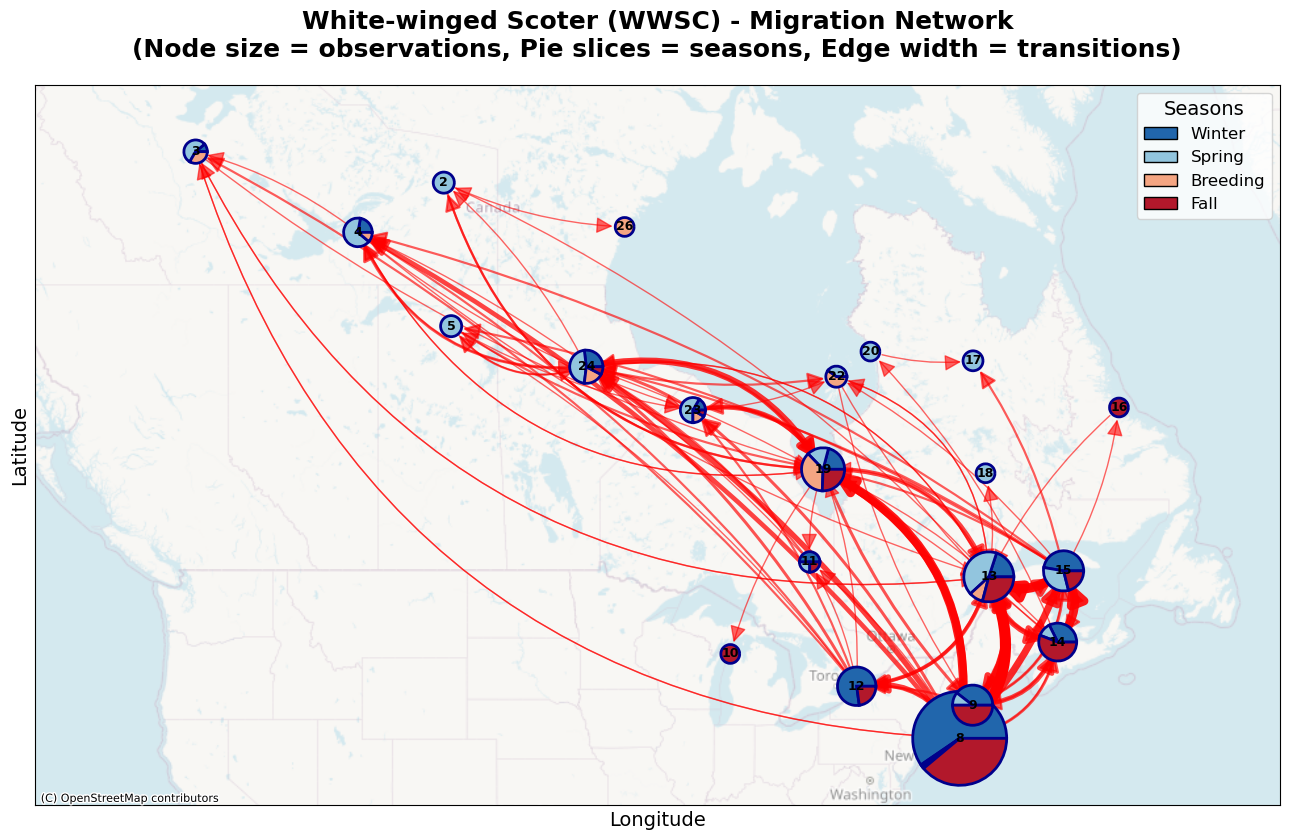

In [3]:
# %% [markdown]
# # White-winged Scoter (WWSC) - Network Analysis
# Analisi della rete di migrazione per i White-winged Scoters

# Filtra solo White-winged Scoter 
df = df_full[df_full['species'] == 'WWSC'].copy()
print(f"White-winged Scoters (WISC)")
print(f"="*60)
print(f"Righe totali SUSC: {len(df)}")
print(f"Individui unici: {df['id'].nunique()}")

print(f"\nDistribuzione per stagione (from_sea):")
print(df['from_sea'].value_counts())

# %%
# Filtra righe con next_cluster valido e rimuovi self-loops
df_valid = df[df['next_cluster'].notna()].copy()
df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)
df_valid['cluster'] = df_valid['cluster'].astype(int)

print(f"Righe con next_cluster valido: {len(df_valid)}")

df_links = df_valid[df_valid['cluster'] != df_valid['next_cluster']].copy()
print(f"Righe dopo rimozione self-loops: {len(df_links)}")

# Cluster coinvolti
clusters_used = sorted(set(df['cluster'].unique()))
print(f"\nCluster usati da BLSC: {clusters_used}")
print(f"Numero di cluster: {len(clusters_used)}")

# %%
# =============================================================================
# CALCOLO PESI DEI LINK (per SUSC)
# =============================================================================
# Contiamo le transizioni tra cluster
edge_weights = df_links.groupby(['cluster', 'next_cluster']).size().reset_index()
edge_weights.columns = ['source', 'target', 'weight']

print(f"Numero di link unici: {len(edge_weights)}")
print(f"\nTop 10 link:")
print(edge_weights.nlargest(10, 'weight'))

# %%
# =============================================================================
# CALCOLO PESI DEI NODI (per SUSC)
# =============================================================================
# Peso del nodo = numero di osservazioni in quel cluster
cluster_weights = df.groupby('cluster').size().reset_index()
cluster_weights.columns = ['cluster', 'total_weight']

print(f"Peso dei cluster (numero osservazioni):")
print(cluster_weights.sort_values('total_weight', ascending=False).head(10))

# Coordinate dei centroidi (calcolate solo su SUSC)
cluster_coords = df.groupby('cluster')[['lon', 'lat']].mean().reset_index()

# Merge per avere coordinate + pesi
cluster_data = cluster_coords.merge(cluster_weights, on='cluster')

# %%
# =============================================================================
# COMPOSIZIONE STAGIONALE PER CLUSTER
# =============================================================================
season_counts = df.groupby(['cluster', 'from_sea']).size().unstack(fill_value=0)
print(f"Composizione stagionale per cluster:")
print(season_counts)

# %%
# =============================================================================
# COSTRUZIONE GRAFO
# =============================================================================
G = nx.DiGraph()

# Aggiungi solo i cluster effettivamente usati da BLSC
G.add_nodes_from(clusters_used)

# Aggiungi archi
for _, row in edge_weights.iterrows():
    G.add_edge(int(row['source']), int(row['target']), weight=row['weight'])

print(f"Grafo BLSC:")
print(f"  Nodi: {G.number_of_nodes()}")
print(f"  Archi: {G.number_of_edges()}")

# %%
# =============================================================================
# TRASFORMAZIONE COORDINATE
# =============================================================================
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

pos = {}
for _, row in cluster_coords.iterrows():
    cluster_id = int(row['cluster'])
    if cluster_id in clusters_used:
        x, y = transformer.transform(row['lon'], row['lat'])
        pos[cluster_id] = (x, y)

# %%
# =============================================================================
# PREPARAZIONE VISUALIZZAZIONE
# =============================================================================
# Normalizza spessori link
weights_list = [G[u][v]['weight'] for u, v in G.edges()]
min_weight_link = min(weights_list) if weights_list else 1
max_weight_link = max(weights_list) if weights_list else 1

if max_weight_link > min_weight_link:
    widths = [1.0 + (8 - 1.0) * (G[u][v]['weight'] - min_weight_link) / (max_weight_link - min_weight_link) 
              for u, v in G.edges()]
    alphas = [0.6 + 0.4 * (G[u][v]['weight'] - min_weight_link) / (max_weight_link - min_weight_link) 
              for u, v in G.edges()]
else:
    widths = [4.0] * len(weights_list)
    alphas = [0.8] * len(weights_list)

# Scala per dimensione nodi
min_weight_scatter = cluster_data['total_weight'].min()
max_weight_scatter = cluster_data['total_weight'].max()

# Colori stagioni
season_colors = {'W': '#2166AC', 'S': '#92C5DE', 'B': '#F4A582', 'F': '#B2182B'}
season_order = ['W', 'S', 'B', 'F']
season_names = {'W': 'Winter', 'S': 'Spring', 'B': 'Breeding', 'F': 'Fall'}

# %%
# =============================================================================
# GRAFICO: TORTE + LINK PESATI (stile Figure 4 del notebook originale)
# =============================================================================
fig, ax = plt.subplots(figsize=(13, 10))

# Identifica link bidirezionali
bidirectional_edges = set()
for u, v in G.edges():
    if G.has_edge(v, u):
        bidirectional_edges.add((min(u, v), max(u, v)))

# Disegna gli archi
for (u, v), width, alpha in zip(G.edges(), widths, alphas):
    edge_pair = (min(u, v), max(u, v))
    
    if edge_pair in bidirectional_edges:
        rad = 0.35 if u < v else -0.35
        connectionstyle = f'arc3,rad={rad}'
    else:
        connectionstyle = 'arc3,rad=0.1'
    
    nx.draw_networkx_edges(G, pos, 
                           edgelist=[(u, v)], 
                           width=width,
                           alpha=alpha,
                           edge_color='red',
                           arrows=True,
                           arrowsize=25,
                           arrowstyle='-|>',
                           connectionstyle=connectionstyle,
                           ax=ax)

# Disegna le torte per ogni cluster
for _, row in cluster_data.iterrows():
    cluster_id = int(row['cluster'])
    if cluster_id not in pos:
        continue
        
    x, y = pos[cluster_id]
    
    if cluster_id in season_counts.index:
        counts = season_counts.loc[cluster_id]
        
        sizes = []
        colors = []
        for season in season_order:
            if season in counts.index and counts[season] > 0:
                sizes.append(counts[season])
                colors.append(season_colors[season])
        
        if len(sizes) > 0:
            weight = row['total_weight']
            # Scala il raggio
            if max_weight_scatter > min_weight_scatter:
                radius = 70000 + (350000 - 70000) * (weight - min_weight_scatter) / (max_weight_scatter - min_weight_scatter)
            else:
                radius = 300000
            
            total = sum(sizes)
            start_angle = 0
            
            for size, color in zip(sizes, colors):
                angle = 360 * size / total
                wedge = Wedge((x, y), radius, start_angle, start_angle + angle,
                             facecolor=color, edgecolor='darkblue', linewidth=2, alpha=1.0)
                ax.add_patch(wedge)
                start_angle += angle
            
            # Etichetta cluster
            ax.text(x, y, str(cluster_id),
                   fontsize=9, fontweight='bold',
                   ha='center', va='center',
                   color='black', zorder=10)

# Imposta limiti
x_coords = [pos[n][0] for n in pos]
y_coords = [pos[n][1] for n in pos]
ax.set_xlim(min(x_coords) - 1200000, max(x_coords) + 1200000)
ax.set_ylim(min(y_coords) - 500000, max(y_coords) + 500000)
ax.set_aspect('equal')

# Aggiungi mappa di sfondo
try:
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=0)
    print("Mappa di sfondo aggiunta!")
except Exception as e:
    print(f"Mappa non disponibile: {e}")
    ax.set_facecolor('#E8F4F8')

# Legenda
legend_elements = [mpatches.Patch(facecolor=season_colors[s], edgecolor='black', 
                                   label=season_names[s]) for s in season_order]
ax.legend(handles=legend_elements, title='Seasons', 
          loc='upper right', fontsize=12, title_fontsize=14)

ax.set_title('White-winged Scoter (WWSC) - Migration Network\n(Node size = observations, Pie slices = seasons, Edge width = transitions)', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)

plt.tight_layout()
plt.show()

White-winged Scoters (WWSC) Males
Righe totali SUSC: 171
Individui unici: 20

Distribuzione per stagione (from_sea):
from_sea
F    68
W    58
S    37
B     8
Name: count, dtype: int64
Righe con next_cluster valido: 151
Righe dopo rimozione self-loops: 104

Cluster usati da BLSC: [np.int64(4), np.int64(5), np.int64(8), np.int64(9), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(19), np.int64(22), np.int64(23), np.int64(24)]
Numero di cluster: 13
Numero di link unici: 44

Top 10 link:
    source  target  weight
30      15      13      10
18      13       8       6
29      14      15       5
2        8      12       4
3        8      13       4
5        8      15       4
6        8      19       4
16      12      13       4
21      13      14       4
22      13      15       4
Peso dei cluster (numero osservazioni):
    cluster  total_weight
2         8            38
5        13            31
7        15            21
4        12            17
6        14  

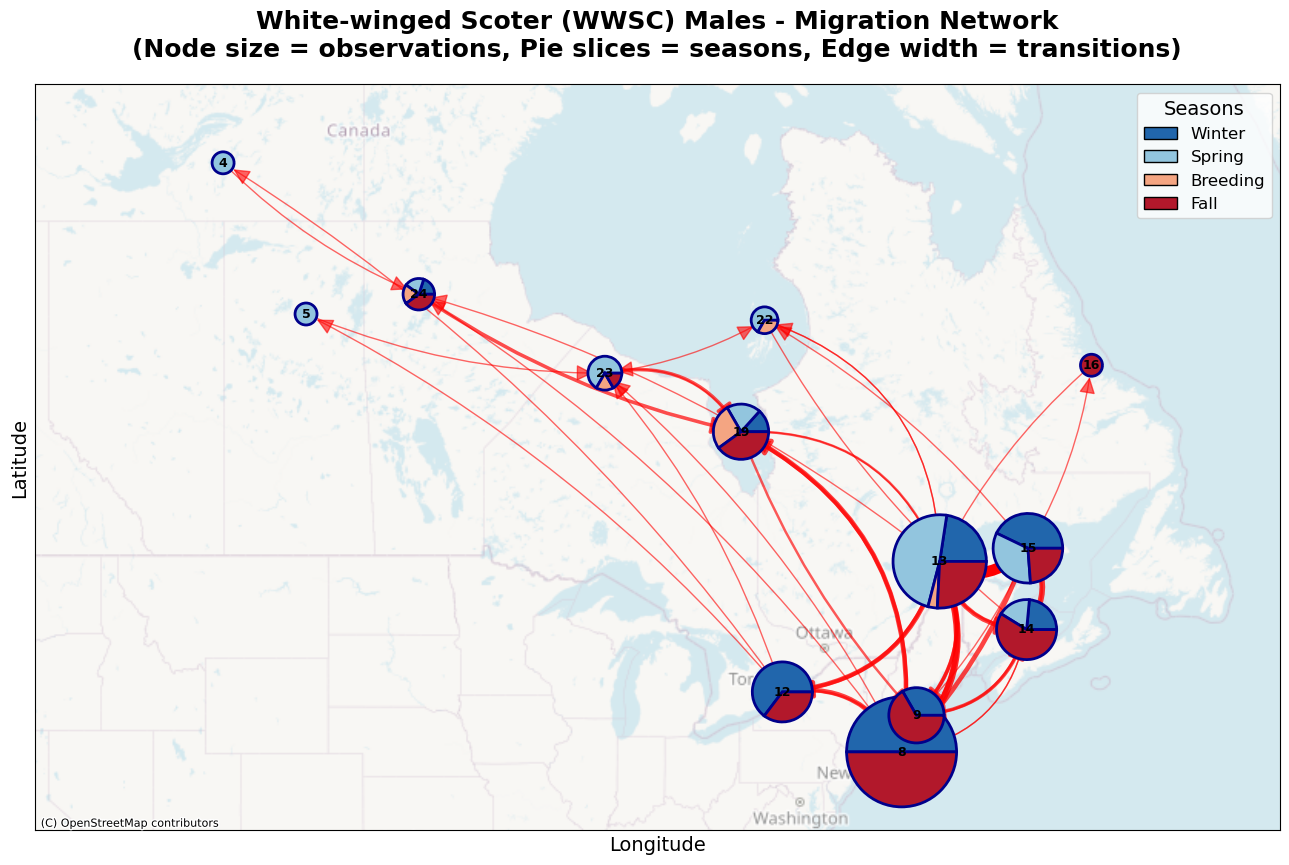

In [4]:
# %% [markdown]
# # White-winged Scoter Males - Network Analysis
# Analisi della rete di migrazione per i White-winged Scoters

# Filtra solo White-winged Scoter 
df = df_full[(df_full['species'] == 'WWSC') & (df_full['sex'] == 'M')].copy()
print(f"White-winged Scoters (WWSC) Males")
print(f"="*60)
print(f"Righe totali SUSC: {len(df)}")
print(f"Individui unici: {df['id'].nunique()}")

print(f"\nDistribuzione per stagione (from_sea):")
print(df['from_sea'].value_counts())

# %%
# Filtra righe con next_cluster valido e rimuovi self-loops
df_valid = df[df['next_cluster'].notna()].copy()
df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)
df_valid['cluster'] = df_valid['cluster'].astype(int)

print(f"Righe con next_cluster valido: {len(df_valid)}")

df_links = df_valid[df_valid['cluster'] != df_valid['next_cluster']].copy()
print(f"Righe dopo rimozione self-loops: {len(df_links)}")

# Cluster coinvolti
clusters_used = sorted(set(df['cluster'].unique()))
print(f"\nCluster usati da BLSC: {clusters_used}")
print(f"Numero di cluster: {len(clusters_used)}")

# %%
# =============================================================================
# CALCOLO PESI DEI LINK (per SUSC)
# =============================================================================
# Contiamo le transizioni tra cluster
edge_weights = df_links.groupby(['cluster', 'next_cluster']).size().reset_index()
edge_weights.columns = ['source', 'target', 'weight']

print(f"Numero di link unici: {len(edge_weights)}")
print(f"\nTop 10 link:")
print(edge_weights.nlargest(10, 'weight'))

# %%
# =============================================================================
# CALCOLO PESI DEI NODI (per SUSC)
# =============================================================================
# Peso del nodo = numero di osservazioni in quel cluster
cluster_weights = df.groupby('cluster').size().reset_index()
cluster_weights.columns = ['cluster', 'total_weight']

print(f"Peso dei cluster (numero osservazioni):")
print(cluster_weights.sort_values('total_weight', ascending=False).head(10))

# Coordinate dei centroidi (calcolate solo su SUSC)
cluster_coords = df.groupby('cluster')[['lon', 'lat']].mean().reset_index()

# Merge per avere coordinate + pesi
cluster_data = cluster_coords.merge(cluster_weights, on='cluster')

# %%
# =============================================================================
# COMPOSIZIONE STAGIONALE PER CLUSTER
# =============================================================================
season_counts = df.groupby(['cluster', 'from_sea']).size().unstack(fill_value=0)
print(f"Composizione stagionale per cluster:")
print(season_counts)

# %%
# =============================================================================
# COSTRUZIONE GRAFO
# =============================================================================
G = nx.DiGraph()

# Aggiungi solo i cluster effettivamente usati da BLSC
G.add_nodes_from(clusters_used)

# Aggiungi archi
for _, row in edge_weights.iterrows():
    G.add_edge(int(row['source']), int(row['target']), weight=row['weight'])

print(f"Grafo BLSC:")
print(f"  Nodi: {G.number_of_nodes()}")
print(f"  Archi: {G.number_of_edges()}")

# %%
# =============================================================================
# TRASFORMAZIONE COORDINATE
# =============================================================================
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

pos = {}
for _, row in cluster_coords.iterrows():
    cluster_id = int(row['cluster'])
    if cluster_id in clusters_used:
        x, y = transformer.transform(row['lon'], row['lat'])
        pos[cluster_id] = (x, y)

# %%
# =============================================================================
# PREPARAZIONE VISUALIZZAZIONE
# =============================================================================
# Normalizza spessori link
weights_list = [G[u][v]['weight'] for u, v in G.edges()]
min_weight_link = min(weights_list) if weights_list else 1
max_weight_link = max(weights_list) if weights_list else 1

if max_weight_link > min_weight_link:
    widths = [1.0 + (8 - 1.0) * (G[u][v]['weight'] - min_weight_link) / (max_weight_link - min_weight_link) 
              for u, v in G.edges()]
    alphas = [0.6 + 0.4 * (G[u][v]['weight'] - min_weight_link) / (max_weight_link - min_weight_link) 
              for u, v in G.edges()]
else:
    widths = [4.0] * len(weights_list)
    alphas = [0.8] * len(weights_list)

# Scala per dimensione nodi
min_weight_scatter = cluster_data['total_weight'].min()
max_weight_scatter = cluster_data['total_weight'].max()

# Colori stagioni
season_colors = {'W': '#2166AC', 'S': '#92C5DE', 'B': '#F4A582', 'F': '#B2182B'}
season_order = ['W', 'S', 'B', 'F']
season_names = {'W': 'Winter', 'S': 'Spring', 'B': 'Breeding', 'F': 'Fall'}

# %%
# =============================================================================
# GRAFICO: TORTE + LINK PESATI (stile Figure 4 del notebook originale)
# =============================================================================
fig, ax = plt.subplots(figsize=(13, 10))

# Identifica link bidirezionali
bidirectional_edges = set()
for u, v in G.edges():
    if G.has_edge(v, u):
        bidirectional_edges.add((min(u, v), max(u, v)))

# Disegna gli archi
for (u, v), width, alpha in zip(G.edges(), widths, alphas):
    edge_pair = (min(u, v), max(u, v))
    
    if edge_pair in bidirectional_edges:
        rad = 0.35 if u < v else -0.35
        connectionstyle = f'arc3,rad={rad}'
    else:
        connectionstyle = 'arc3,rad=0.1'
    
    nx.draw_networkx_edges(G, pos, 
                           edgelist=[(u, v)], 
                           width=width,
                           alpha=alpha,
                           edge_color='red',
                           arrows=True,
                           arrowsize=25,
                           arrowstyle='-|>',
                           connectionstyle=connectionstyle,
                           ax=ax)

# Disegna le torte per ogni cluster
for _, row in cluster_data.iterrows():
    cluster_id = int(row['cluster'])
    if cluster_id not in pos:
        continue
        
    x, y = pos[cluster_id]
    
    if cluster_id in season_counts.index:
        counts = season_counts.loc[cluster_id]
        
        sizes = []
        colors = []
        for season in season_order:
            if season in counts.index and counts[season] > 0:
                sizes.append(counts[season])
                colors.append(season_colors[season])
        
        if len(sizes) > 0:
            weight = row['total_weight']
            # Scala il raggio
            if max_weight_scatter > min_weight_scatter:
                radius = 70000 + (350000 - 70000) * (weight - min_weight_scatter) / (max_weight_scatter - min_weight_scatter)
            else:
                radius = 300000
            
            total = sum(sizes)
            start_angle = 0
            
            for size, color in zip(sizes, colors):
                angle = 360 * size / total
                wedge = Wedge((x, y), radius, start_angle, start_angle + angle,
                             facecolor=color, edgecolor='darkblue', linewidth=2, alpha=1.0)
                ax.add_patch(wedge)
                start_angle += angle
            
            # Etichetta cluster
            ax.text(x, y, str(cluster_id),
                   fontsize=9, fontweight='bold',
                   ha='center', va='center',
                   color='black', zorder=10)

# Imposta limiti
x_coords = [pos[n][0] for n in pos]
y_coords = [pos[n][1] for n in pos]
ax.set_xlim(min(x_coords) - 1200000, max(x_coords) + 1200000)
ax.set_ylim(min(y_coords) - 500000, max(y_coords) + 500000)
ax.set_aspect('equal')

# Aggiungi mappa di sfondo
try:
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=0)
    print("Mappa di sfondo aggiunta!")
except Exception as e:
    print(f"Mappa non disponibile: {e}")
    ax.set_facecolor('#E8F4F8')

# Legenda
legend_elements = [mpatches.Patch(facecolor=season_colors[s], edgecolor='black', 
                                   label=season_names[s]) for s in season_order]
ax.legend(handles=legend_elements, title='Seasons', 
          loc='upper right', fontsize=12, title_fontsize=14)

ax.set_title('White-winged Scoter (WWSC) Males - Migration Network\n(Node size = observations, Pie slices = seasons, Edge width = transitions)', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)

plt.tight_layout()
plt.show()

White-winged Scoters (WWSC) Females
Righe totali SUSC: 295
Individui unici: 58

Distribuzione per stagione (from_sea):
from_sea
W    127
F     70
S     68
B     30
Name: count, dtype: int64
Righe con next_cluster valido: 237
Righe dopo rimozione self-loops: 155

Cluster usati da BLSC: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(22), np.int64(23), np.int64(24), np.int64(26)]
Numero di cluster: 20
Numero di link unici: 73

Top 10 link:
    source  target  weight
13       8       9       7
37      13       8       7
19       8      19       6
12       8       4       5
21       8      24       5
43      14      15       5
56      19       8       5
16       8      13       4
18       8      15       4
22       9       8       4
Peso dei cluster (numero osservazioni):
    cluster  total_weight
4         8    

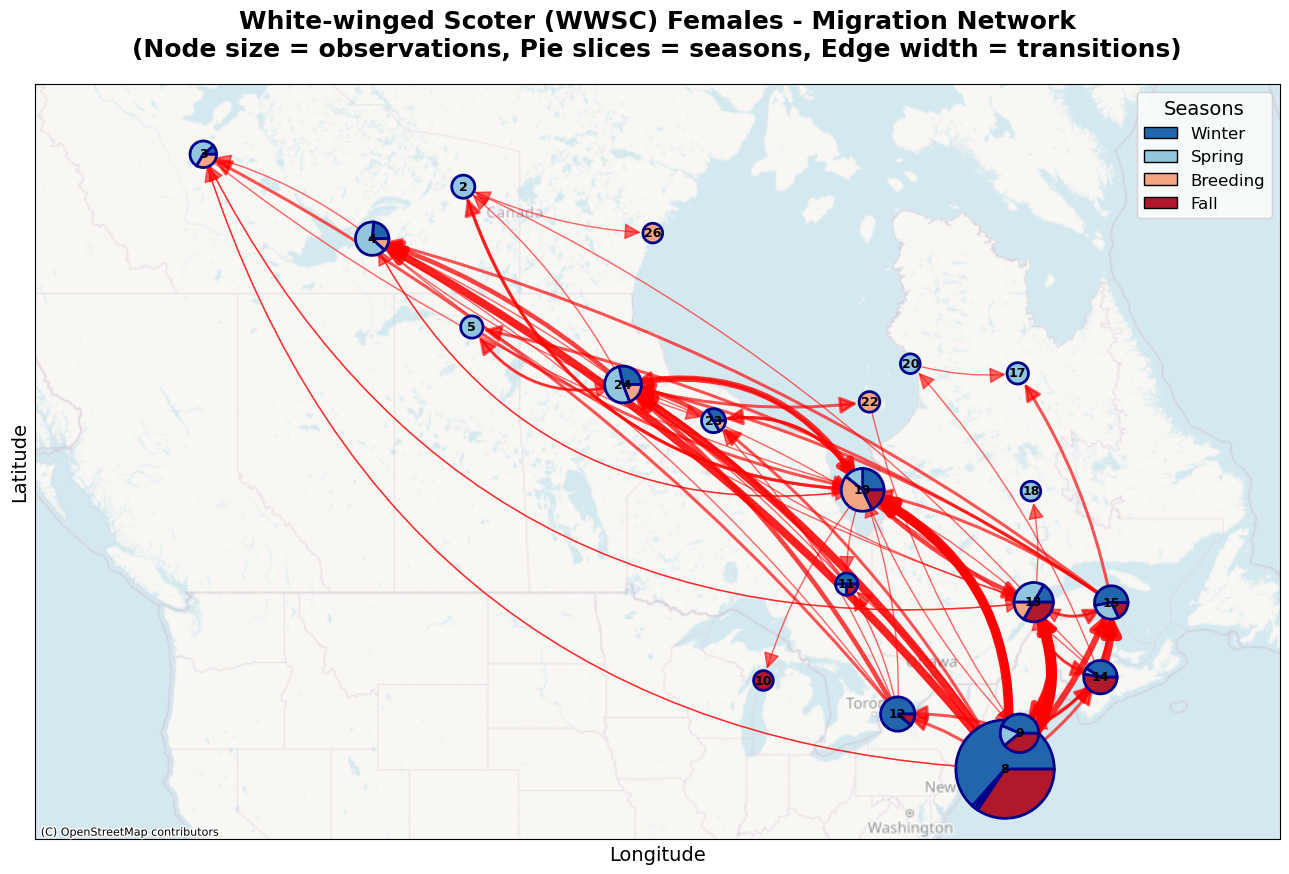

In [5]:
# %% [markdown]
# # White-winged Scoter Females - Network Analysis
# Analisi della rete di migrazione per i White-winged Scoters

# Filtra solo White-winged Scoter 
df = df_full[(df_full['species'] == 'WWSC') & (df_full['sex'] == 'F')].copy()
print(f"White-winged Scoters (WWSC) Females")
print(f"="*60)
print(f"Righe totali SUSC: {len(df)}")
print(f"Individui unici: {df['id'].nunique()}")

print(f"\nDistribuzione per stagione (from_sea):")
print(df['from_sea'].value_counts())

# %%
# Filtra righe con next_cluster valido e rimuovi self-loops
df_valid = df[df['next_cluster'].notna()].copy()
df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)
df_valid['cluster'] = df_valid['cluster'].astype(int)

print(f"Righe con next_cluster valido: {len(df_valid)}")

df_links = df_valid[df_valid['cluster'] != df_valid['next_cluster']].copy()
print(f"Righe dopo rimozione self-loops: {len(df_links)}")

# Cluster coinvolti
clusters_used = sorted(set(df['cluster'].unique()))
print(f"\nCluster usati da BLSC: {clusters_used}")
print(f"Numero di cluster: {len(clusters_used)}")

# %%
# =============================================================================
# CALCOLO PESI DEI LINK (per SUSC)
# =============================================================================
# Contiamo le transizioni tra cluster
edge_weights = df_links.groupby(['cluster', 'next_cluster']).size().reset_index()
edge_weights.columns = ['source', 'target', 'weight']

print(f"Numero di link unici: {len(edge_weights)}")
print(f"\nTop 10 link:")
print(edge_weights.nlargest(10, 'weight'))

# %%
# =============================================================================
# CALCOLO PESI DEI NODI (per SUSC)
# =============================================================================
# Peso del nodo = numero di osservazioni in quel cluster
cluster_weights = df.groupby('cluster').size().reset_index()
cluster_weights.columns = ['cluster', 'total_weight']

print(f"Peso dei cluster (numero osservazioni):")
print(cluster_weights.sort_values('total_weight', ascending=False).head(10))

# Coordinate dei centroidi (calcolate solo su SUSC)
cluster_coords = df.groupby('cluster')[['lon', 'lat']].mean().reset_index()

# Merge per avere coordinate + pesi
cluster_data = cluster_coords.merge(cluster_weights, on='cluster')

# %%
# =============================================================================
# COMPOSIZIONE STAGIONALE PER CLUSTER
# =============================================================================
season_counts = df.groupby(['cluster', 'from_sea']).size().unstack(fill_value=0)
print(f"Composizione stagionale per cluster:")
print(season_counts)

# %%
# =============================================================================
# COSTRUZIONE GRAFO
# =============================================================================
G = nx.DiGraph()

# Aggiungi solo i cluster effettivamente usati da BLSC
G.add_nodes_from(clusters_used)

# Aggiungi archi
for _, row in edge_weights.iterrows():
    G.add_edge(int(row['source']), int(row['target']), weight=row['weight'])

print(f"Grafo BLSC:")
print(f"  Nodi: {G.number_of_nodes()}")
print(f"  Archi: {G.number_of_edges()}")

# %%
# =============================================================================
# TRASFORMAZIONE COORDINATE
# =============================================================================
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

pos = {}
for _, row in cluster_coords.iterrows():
    cluster_id = int(row['cluster'])
    if cluster_id in clusters_used:
        x, y = transformer.transform(row['lon'], row['lat'])
        pos[cluster_id] = (x, y)

# %%
# =============================================================================
# PREPARAZIONE VISUALIZZAZIONE
# =============================================================================
# Normalizza spessori link
weights_list = [G[u][v]['weight'] for u, v in G.edges()]
min_weight_link = min(weights_list) if weights_list else 1
max_weight_link = max(weights_list) if weights_list else 1

if max_weight_link > min_weight_link:
    widths = [1.0 + (8 - 1.0) * (G[u][v]['weight'] - min_weight_link) / (max_weight_link - min_weight_link) 
              for u, v in G.edges()]
    alphas = [0.6 + 0.4 * (G[u][v]['weight'] - min_weight_link) / (max_weight_link - min_weight_link) 
              for u, v in G.edges()]
else:
    widths = [4.0] * len(weights_list)
    alphas = [0.8] * len(weights_list)

# Scala per dimensione nodi
min_weight_scatter = cluster_data['total_weight'].min()
max_weight_scatter = cluster_data['total_weight'].max()

# Colori stagioni
season_colors = {'W': '#2166AC', 'S': '#92C5DE', 'B': '#F4A582', 'F': '#B2182B'}
season_order = ['W', 'S', 'B', 'F']
season_names = {'W': 'Winter', 'S': 'Spring', 'B': 'Breeding', 'F': 'Fall'}

# %%
# =============================================================================
# GRAFICO: TORTE + LINK PESATI (stile Figure 4 del notebook originale)
# =============================================================================
fig, ax = plt.subplots(figsize=(13, 10))

# Identifica link bidirezionali
bidirectional_edges = set()
for u, v in G.edges():
    if G.has_edge(v, u):
        bidirectional_edges.add((min(u, v), max(u, v)))

# Disegna gli archi
for (u, v), width, alpha in zip(G.edges(), widths, alphas):
    edge_pair = (min(u, v), max(u, v))
    
    if edge_pair in bidirectional_edges:
        rad = 0.35 if u < v else -0.35
        connectionstyle = f'arc3,rad={rad}'
    else:
        connectionstyle = 'arc3,rad=0.1'
    
    nx.draw_networkx_edges(G, pos, 
                           edgelist=[(u, v)], 
                           width=width,
                           alpha=alpha,
                           edge_color='red',
                           arrows=True,
                           arrowsize=25,
                           arrowstyle='-|>',
                           connectionstyle=connectionstyle,
                           ax=ax)

# Disegna le torte per ogni cluster
for _, row in cluster_data.iterrows():
    cluster_id = int(row['cluster'])
    if cluster_id not in pos:
        continue
        
    x, y = pos[cluster_id]
    
    if cluster_id in season_counts.index:
        counts = season_counts.loc[cluster_id]
        
        sizes = []
        colors = []
        for season in season_order:
            if season in counts.index and counts[season] > 0:
                sizes.append(counts[season])
                colors.append(season_colors[season])
        
        if len(sizes) > 0:
            weight = row['total_weight']
            # Scala il raggio
            if max_weight_scatter > min_weight_scatter:
                radius = 70000 + (350000 - 70000) * (weight - min_weight_scatter) / (max_weight_scatter - min_weight_scatter)
            else:
                radius = 300000
            
            total = sum(sizes)
            start_angle = 0
            
            for size, color in zip(sizes, colors):
                angle = 360 * size / total
                wedge = Wedge((x, y), radius, start_angle, start_angle + angle,
                             facecolor=color, edgecolor='darkblue', linewidth=2, alpha=1.0)
                ax.add_patch(wedge)
                start_angle += angle
            
            # Etichetta cluster
            ax.text(x, y, str(cluster_id),
                   fontsize=9, fontweight='bold',
                   ha='center', va='center',
                   color='black', zorder=10)

# Imposta limiti
x_coords = [pos[n][0] for n in pos]
y_coords = [pos[n][1] for n in pos]
ax.set_xlim(min(x_coords) - 1200000, max(x_coords) + 1200000)
ax.set_ylim(min(y_coords) - 500000, max(y_coords) + 500000)
ax.set_aspect('equal')

# Aggiungi mappa di sfondo
try:
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=0)
    print("Mappa di sfondo aggiunta!")
except Exception as e:
    print(f"Mappa non disponibile: {e}")
    ax.set_facecolor('#E8F4F8')

# Legenda
legend_elements = [mpatches.Patch(facecolor=season_colors[s], edgecolor='black', 
                                   label=season_names[s]) for s in season_order]
ax.legend(handles=legend_elements, title='Seasons', 
          loc='upper right', fontsize=12, title_fontsize=14)

ax.set_title('White-winged Scoter (WWSC) Females - Migration Network\n(Node size = observations, Pie slices = seasons, Edge width = transitions)', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)

plt.tight_layout()
plt.show()